# MatchState: Live Win Probability Model for EPL Soccer

Research notebook walking through the project end to end: data, the
Dixon-Coles baseline, a hierarchical Bayesian extension, a possession-value
(xT) model, in-game features, a gradient boosting model, calibration, a
betting-market benchmark, and statistically rigorous validation.

This notebook is a narrative companion to the modular codebase (`baseline/`,
`bayesian/`, `possession_value/`, `features/`, `models/`, `calibration/`,
`market/`, `backtest/`) -- it reruns the key analyses inline with real
output rather than duplicating every script. Full results and honest
findings are in `RESULTS.md` at the repo root.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    # robust to the kernel's cwd being the notebook's own directory
    # (nbconvert's default) rather than the repo root
    for p in [start, *start.parents]:
        if (p / "requirements.txt").exists() and (p / "baseline").is_dir():
            return p
    raise RuntimeError("could not locate repo root from " + str(start))


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 100


## 1. Data

Three sources: football-data.co.uk (33 EPL seasons of results + odds),
StatsBomb open data (event-level detail, but only 380 usable matches --
2015/16, the Leicester title season), and Understat (match xG, 2014/15
onward). See `data/README.md` for the full disclosed coverage constraints
that shape everything downstream.

In [2]:
from baseline.data import load_results

results = load_results()
print(f"{len(results):,} EPL matches, {results['Season'].min()} to {results['Season'].max()}")
results[results["Season"] == "2015/16"].head()


12,704 EPL matches, 1993/94 to 2025/26


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Season
8524,2015-08-08,Norwich,Crystal Palace,1,3,A,2015/16
8525,2015-08-08,Man United,Tottenham,1,0,H,2015/16
8526,2015-08-08,Bournemouth,Aston Villa,0,1,A,2015/16
8527,2015-08-08,Everton,Watford,2,2,D,2015/16
8528,2015-08-08,Chelsea,Swansea,2,2,D,2015/16


## 2. Dixon-Coles Poisson Baseline

Attack/defense strength per team, fit by maximum likelihood, with the
Dixon-Coles low-score correction. Fit here on 2015/16 -- Leicester's
title-winning season, a good real-world check since we know the answer.

In [3]:
from baseline.dixon_coles import DixonColes

season_df = results[results["Season"] == "2015/16"]
dc_model = DixonColes().fit(season_df)

strength = pd.DataFrame({
    "attack": dc_model.attack,
    "defense": dc_model.defense,
}).assign(overall=lambda d: d.attack - d.defense).sort_values("overall", ascending=False)
print(f"home_adv={dc_model.home_adv:+.3f}   rho={dc_model.rho:+.3f}")
strength.head(6)


home_adv=+0.335   rho=-0.065


,attack,defense,overall
Tottenham,0.332554,-0.356480,0.689033
Leicester,0.318850,-0.338015,0.656866
Arsenal,0.273794,-0.329453,0.603247
Man City,0.374096,-0.179407,0.553503
Southampton,0.170612,-0.204890,0.375501
Man United,-0.024243,-0.387293,0.363050


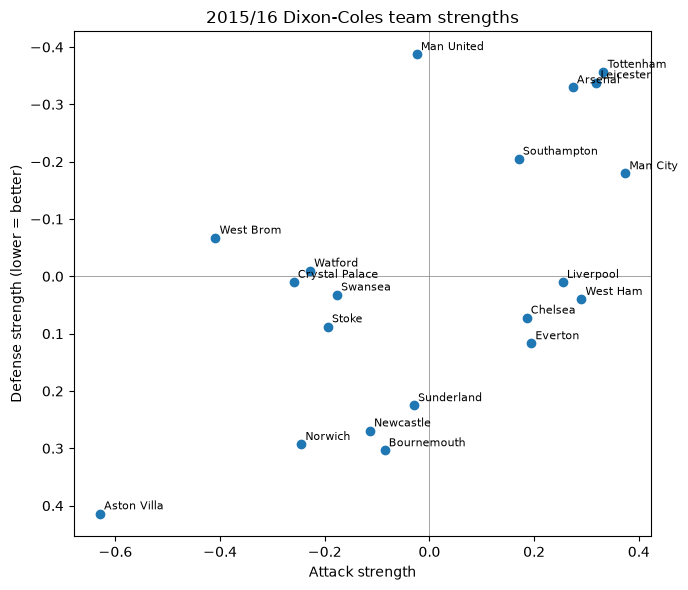

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(strength["attack"], strength["defense"])
for team, row in strength.iterrows():
    ax.annotate(team, (row["attack"], row["defense"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Attack strength")
ax.set_ylabel("Defense strength (lower = better)")
ax.set_title("2015/16 Dixon-Coles team strengths")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [5]:
p = dc_model.match_probabilities("Leicester", "Aston Villa")
print(f"Leicester vs Aston Villa (pre-match): home_win={p['home_win']:.3f} draw={p['draw']:.3f} away_win={p['away_win']:.3f}")

p_late = dc_model.in_game_probabilities("Leicester", "Aston Villa", minute=89, home_goals=1, away_goals=0)
print(f"Leicester 1-0 up, 89': home_win={p_late['home_win']:.3f} draw={p_late['draw']:.3f} away_win={p_late['away_win']:.3f}")

two_up = dc_model.in_game_probabilities("Leicester", "Aston Villa", minute=89, home_goals=2, away_goals=1)
print(f"Leicester 2-1 up, 89': home_win={two_up['home_win']:.3f}  (sanity check: should be >0.95)")


Leicester vs Aston Villa (pre-match): home_win=0.878 draw=0.097 away_win=0.025
Leicester 1-0 up, 89': home_win=0.996 draw=0.004 away_win=0.000
Leicester 2-1 up, 89': home_win=0.996  (sanity check: should be >0.95)


**Sanity check across all 33 seasons** (`baseline/fit.py`): home advantage
is positive in every single season, and drops sharply in **2020/21**
(+0.20 vs. a typical +0.3-0.4) -- the empty-stadiums COVID season, an
effect recovered from goals data alone, without being told about it.

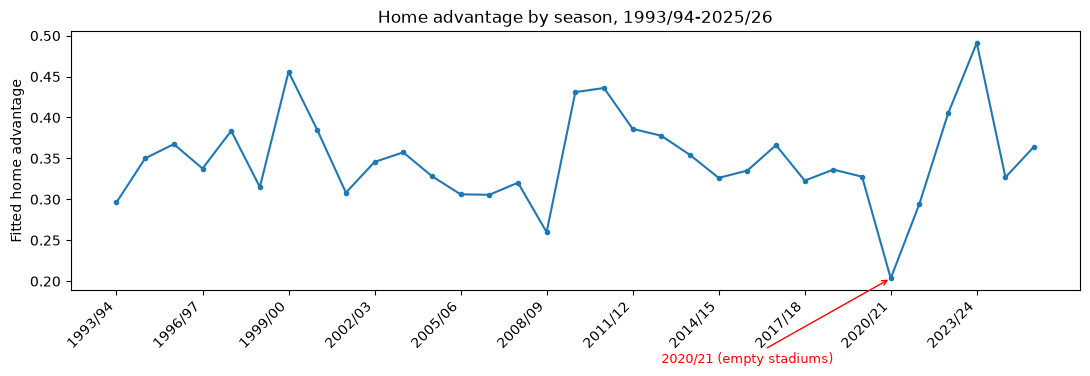

In [6]:
season_summary = json.loads(Path(REPO_ROOT / "data/processed/bayesian_vs_static.json").read_text())
# home_adv isn't in that file (it's the Bayesian model's output) -- pull straight from the per-season DC fits
home_advs = []
for path in sorted(Path(REPO_ROOT / "data/processed/dixon_coles").glob("*.json")):
    d = json.loads(path.read_text())
    home_advs.append({"season": d["season"], "home_adv": d["home_adv"]})
hadv_df = pd.DataFrame(home_advs)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hadv_df["season"], hadv_df["home_adv"], marker="o", ms=3)
covid_idx = hadv_df.index[hadv_df["season"] == "2020/21"][0]
ax.annotate("2020/21 (empty stadiums)", (covid_idx, hadv_df.loc[covid_idx, "home_adv"]),
            xytext=(covid_idx - 8, 0.1), fontsize=9, color="red",
            arrowprops=dict(arrowstyle="->", color="red"))
ax.set_xticks(range(0, len(hadv_df), 3))
ax.set_xticklabels(hadv_df["season"][::3], rotation=45, ha="right")
ax.set_ylabel("Fitted home advantage")
ax.set_title("Home advantage by season, 1993/94-2025/26")
plt.tight_layout()
plt.show()


## 3. Hierarchical Bayesian Team-Strength Model

Lets attack/defense drift within a season via a partially-pooled random
walk, rather than one fixed number all season. Fitting live here (NUTS,
~5-10s) on the same season for a direct comparison.

In [7]:
from bayesian.model import HierarchicalDixonColes

bayes_model = HierarchicalDixonColes(n_periods=8).fit(season_df, draws=800, tune=800, chains=4, random_seed=42)
traj = bayes_model.strength_trajectory()


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma_attack_init, sigma_defense_init, sigma_walk_attack, sigma_walk_defense, attack_init_raw, defense_init_raw, attack_innov_raw, defense_innov_raw, home_adv]


Output()

Sampling 4 chains for 800 tune and 800 draw iterations (3_200 + 3_200 draws total) took 6 seconds.


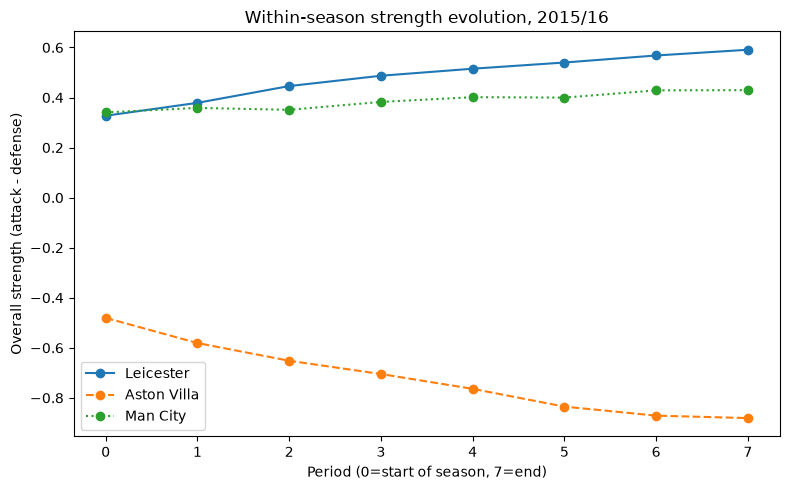

Leicester's strength rises every single period -- driven mainly by defense (see bayesian/README.md).


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for team, style in [("Leicester", "-"), ("Aston Villa", "--"), ("Man City", ":")]:
    t = traj[traj["team"] == team].sort_values("period")
    ax.plot(t["period"], t["attack"] - t["defense"], style, marker="o", label=team)
ax.set_xlabel("Period (0=start of season, 7=end)")
ax.set_ylabel("Overall strength (attack - defense)")
ax.set_title("Within-season strength evolution, 2015/16")
ax.legend()
plt.tight_layout()
plt.show()
print("Leicester's strength rises every single period -- driven mainly by defense (see bayesian/README.md).")


In [9]:
import json
season_comparison = json.loads(Path(REPO_ROOT / "data/processed/bayesian_vs_static.json").read_text())
briers_static = np.array([r["static_brier"] for r in season_comparison])
briers_dyn = np.array([r["dynamic_brier"] for r in season_comparison])
wins = int((briers_dyn < briers_static).sum())
print(f"Across all {len(season_comparison)} EPL seasons: dynamic Bayesian beats static Dixon-Coles in "
      f"{wins}/{len(season_comparison)} seasons (mean Brier {briers_dyn.mean():.4f} vs {briers_static.mean():.4f}).")
print("The bootstrap analysis found this gap is NOT statistically significant on the single-season in-game test --")
print("directional evidence across 33 seasons, but not proven at 95% confidence on the smaller matched sample.")


Across all 33 EPL seasons: dynamic Bayesian beats static Dixon-Coles in 22/33 seasons (mean Brier 0.5878 vs 0.5893).
The bootstrap analysis found this gap is NOT statistically significant on the single-season in-game test --
directional evidence across 33 seasons, but not proven at 95% confidence on the smaller matched sample.


**A bug caught and fixed during this step, worth recording:** the first
convergence-diagnostics run reported 30/33 seasons with "convergence
warnings" (max r_hat >= 1.01). That turned out to be a false alarm caused
by `arviz.summary()`'s `round_to` parameter -- it needs the *string*
`"none"` to return full-precision r_hat, not Python `None`; passing `None`
silently falls back to its 2-decimal default, so r_hat values that were
genuinely 1.005-1.014 all displayed as the boundary value "1.01" and
tripped a `< 1.01` check. Fixed and rerun: real number is 6/33 seasons
with only borderline flags (max r_hat 1.004-1.014 range), no actual
divergence problems. All 33 seasons sampled cleanly (4 chains, ~5-10s
each, <=1 divergent transition out of 3,200 draws in every case).

## 4. Possession-Value Momentum Model

An Expected Threat (xT) grid, fit on 655K parsed StatsBomb actions from
2015/16, via value iteration. Loading the already-fitted grid.

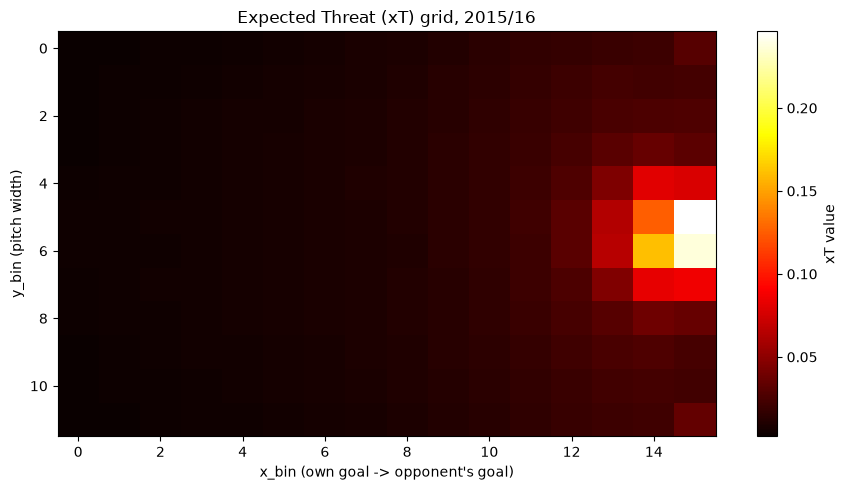

Sanity check: 0/15 non-monotonic steps moving toward goal (0 = perfectly monotonic).


In [10]:
from possession_value.xt_model import ExpectedThreat, N_X_BINS, N_Y_BINS

xt_model = ExpectedThreat.load(Path(REPO_ROOT / "data/processed/xt_grid_2015_16.npz"))
grid = xt_model.xt_grid.reshape(N_X_BINS, N_Y_BINS)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(grid.T, origin="upper", cmap="hot", aspect="auto")
ax.set_xlabel("x_bin (own goal -> opponent's goal)")
ax.set_ylabel("y_bin (pitch width)")
ax.set_title("Expected Threat (xT) grid, 2015/16")
fig.colorbar(im, ax=ax, label="xT value")
plt.tight_layout()
plt.show()

by_x = grid.mean(axis=1)
n_decreases = int((np.diff(by_x) < 0).sum())
print(f"Sanity check: {n_decreases}/15 non-monotonic steps moving toward goal (0 = perfectly monotonic).")


## 5. In-Game State & Lineup-Aware Features

One row per (match, minute): score, running xG differential, the
possession-value model's momentum, red cards, and substitution quality (weighted
by each player's season-long attacking contribution).

In [11]:
features = pd.read_parquet(REPO_ROOT / "data/processed/ingame_features_2015_16.parquet")
print(f"{len(features):,} rows, {features['match_id'].nunique()} matches")
features[features["match_id"] == 3754217].iloc[[0, 45, 52, 78, 90]][
    ["minute", "score_diff", "xg_diff", "momentum_5min_diff", "red_cards_diff", "sub_quality_diff"]
]


36,125 rows, 380 matches


,minute,score_diff,xg_diff,momentum_5min_diff,red_cards_diff,sub_quality_diff
0,0,0,0.000000,0.006219,0,0.000000
45,45,0,0.609958,-0.061208,-1,0.026840
52,52,1,0.738776,0.236560,-1,0.026840
78,78,1,0.874902,-0.043501,-2,0.433218
90,90,2,1.231430,0.054182,-2,0.403849


**Validating the substitution-quality proxy.** Each player is scored by
season-long xT contribution per 90 minutes (shrunk toward the league
average for low-minute players), so a substitution's *quality* -- not
just its occurrence -- feeds the model. Loading the fitted quality table:

In [12]:
quality = pd.read_parquet(REPO_ROOT / "data/processed/player_quality_2015_16.parquet")
print("Top 10 by quality_per90 (>=900 minutes played):")
display(quality[quality["minutes"] >= 900].head(10)[["player_name", "minutes", "quality_per90"]])
print("\nMesut Ozil ranks #1 -- he set the Premier League single-season assist record (19) in exactly this")
print("2015/16 season. Bottom of the list (not shown) is goalkeepers and target-man strikers (Benteke, Bony,")
print("Pelle) -- matching the disclosed limitation that this proxy only credits ball progression, not")
print("finishing or shot-stopping.")


Top 10 by quality_per90 (>=900 minutes played):


,player_name,minutes,quality_per90
373,Mesut Özil,3125,0.482162
132,Dimitri Payet,2677,0.481267
180,Gerard Deulofeu Lázaro,1445,0.400994
137,Dušan Tadić,2339,0.364866
302,Kevin De Bruyne,2077,0.359232
462,Santiago Cazorla González,1332,0.353619
539,Willian Borges da Silva,2840,0.339626
224,James Philip Milner,2495,0.319512
27,Alexis Alejandro Sánchez Sánchez,2510,0.316370
325,Leighton Baines,1553,0.311585



Mesut Ozil ranks #1 -- he set the Premier League single-season assist record (19) in exactly this
2015/16 season. Bottom of the list (not shown) is goalkeepers and target-man strikers (Benteke, Bony,
Pelle) -- matching the disclosed limitation that this proxy only credits ball progression, not
finishing or shot-stopping.


**Whole-dataset validation, not just a spot check.** Every match's
StatsBomb-tracked goal events were compared against football-data.co.uk's
independently-sourced results for all 380 matches.

In [13]:
last_rows = features.sort_values("minute").groupby("match_id").tail(1)
mismatches = last_rows[
    (last_rows["home_goals"] != last_rows["final_home_goals"]) | (last_rows["away_goals"] != last_rows["final_away_goals"])
]
print(f"Exact scoreline mismatches across all {len(last_rows)} matches: {len(mismatches)}")
print(f"Null values anywhere in the {len(features):,}-row table: {int(features.isna().sum().sum())}")


Exact scoreline mismatches across all 380 matches: 0
Null values anywhere in the 36,125-row table: 0


## 6. Gradient Boosting Win Probability Model

XGBoost trained on the in-game features, compared against both baselines
on the same held-out matches. Loading its evaluation result.

,brier,logloss
model,,
Static Dixon-Coles,0.297848,0.513691
Hierarchical Bayesian,0.292252,0.514077
Gradient Boosting,0.311017,0.571643


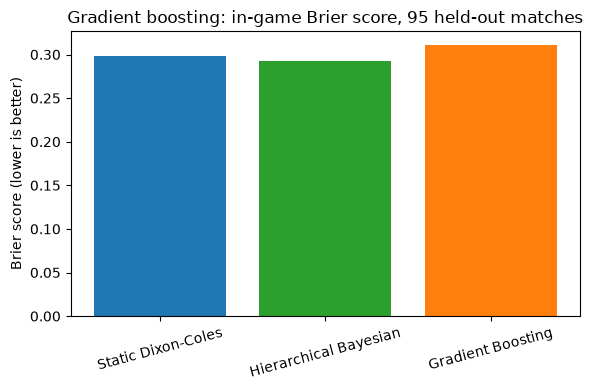

GBM loses on the aggregate, but wins clearly in the first 30 minutes of a match (see models/README.md) --
exactly when momentum/xG/cards carry signal the Poisson-family models structurally can't see.


In [14]:
gbm_comparison = json.loads(Path(REPO_ROOT / "data/processed/gbm_vs_baselines.json").read_text())
comp_df = pd.DataFrame(gbm_comparison).set_index("model")
display(comp_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(comp_df.index, comp_df["brier"], color=["tab:blue", "tab:green", "tab:orange"])
ax.set_ylabel("Brier score (lower is better)")
ax.set_title("Gradient boosting: in-game Brier score, 95 held-out matches")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print("GBM loses on the aggregate, but wins clearly in the first 30 minutes of a match (see models/README.md) --")
print("exactly when momentum/xG/cards carry signal the Poisson-family models structurally can't see.")


**Phase breakdown** -- GBM's early-match win, and late-match weakness,
made concrete:

| Phase | Static | Bayesian | GBM |
|---|---|---|---|
| 0-30' | 0.5765 | 0.5727 | **0.5492** |
| 30-60' | 0.4926 | 0.4871 | 0.5033 |
| 60'+ | 0.2733 | 0.2710 | 0.2985 |

**Formation was tried as a feature, and dropped -- a measured decision,
not an assumption.** It initially looked informative (~15% combined
feature importance), but several clubs used one formation almost
exclusively that season (Arsenal 4-2-3-1 in 19/19 home matches, Chelsea
18/19, Leicester 4-4-2 in 16/19) -- with only 20 teams total and no
unseen-team holdout, formation functions as a near-team-identity
fingerprint. Confirmed empirically: held-out Brier score was *worse* with
formation included (0.3441) than without (0.3110). Removed from the
shipped feature set.

**A concrete illustration of the late-game weakness:** every one of 58
held-out snapshots with a 2+ goal lead around minute 80 ended in a win for
the leading team. Static Dixon-Coles correctly assigns near-certainty
there (0.97-0.999); GBM is systematically underconfident (0.79-0.95) --
with only 285 training matches, it hasn't seen enough of these rare,
extreme late-game states to learn how close to certain they really are.

## 7. Big-Moment Detection

Flags the largest win-probability swings per match. The Chelsea 2-0
Arsenal match (two Arsenal red cards) is a clean illustration: Dixon-Coles
and the Bayesian model only ever see score/time, so they're structurally
blind to red cards -- GBM isn't.

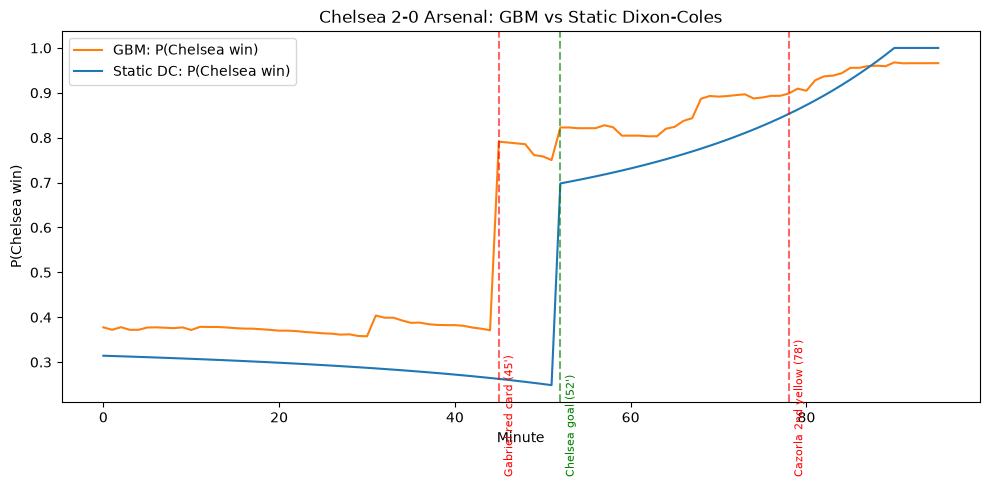

At minute 45, GBM's P(home win) jumps sharply on the red card; static Dixon-Coles barely moves --
confirmed across all 16 red cards in the test set (models/README.md): mean swing 0.157 (GBM) vs 0.005 (static).


In [15]:
from models.gbm import train_gbm, predict_proba_dicts, match_level_split
import json as _json

matches_meta = _json.load(open(REPO_ROOT / "data/raw/statsbomb/matches/2_27.json"))
match_dates = {m["match_id"]: pd.Timestamp(m["match_date"]) for m in matches_meta}
fit_df, val_df = match_level_split(features, match_dates, train_frac=0.85)
gbm_model = train_gbm(fit_df, val_df)

match_id = 3754217
match_rows = features[features["match_id"] == match_id].sort_values("minute").reset_index(drop=True)
home, away = match_rows["home_team"].iloc[0], match_rows["away_team"].iloc[0]
gbm_probs = predict_proba_dicts(gbm_model, match_rows)

from data.team_names import to_football_data
home_fd, away_fd = to_football_data(home), to_football_data(away)
static_probs = [dc_model.in_game_probabilities(home_fd, away_fd, r.minute, r.home_goals, r.away_goals) for r in match_rows.itertuples()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(match_rows["minute"], [p["home_win"] for p in gbm_probs], label="GBM: P(Chelsea win)", color="tab:orange")
ax.plot(match_rows["minute"], [p["home_win"] for p in static_probs], label="Static DC: P(Chelsea win)", color="tab:blue")
ax.axvline(45, color="red", linestyle="--", alpha=0.6)
ax.text(45.5, 0.05, "Gabriel red card (45')", rotation=90, fontsize=8, color="red")
ax.axvline(78, color="red", linestyle="--", alpha=0.6)
ax.text(78.5, 0.05, "Cazorla 2nd yellow (78')", rotation=90, fontsize=8, color="red")
ax.axvline(52, color="green", linestyle="--", alpha=0.6)
ax.text(52.5, 0.05, "Chelsea goal (52')", rotation=90, fontsize=8, color="green")
ax.set_xlabel("Minute")
ax.set_ylabel("P(Chelsea win)")
ax.set_title(f"{home} {int(match_rows['final_home_goals'].iloc[0])}-{int(match_rows['final_away_goals'].iloc[0])} {away}: GBM vs Static Dixon-Coles")
ax.legend()
plt.tight_layout()
plt.show()
print("At minute 45, GBM's P(home win) jumps sharply on the red card; static Dixon-Coles barely moves --")
print("confirmed across all 16 red cards in the test set (models/README.md): mean swing 0.157 (GBM) vs 0.005 (static).")


## 8. Probability Calibration

Platt scaling and isotonic regression, evaluated per outcome class.
Reliability diagrams were saved to `calibration/plots/`; displaying the
static model's here.

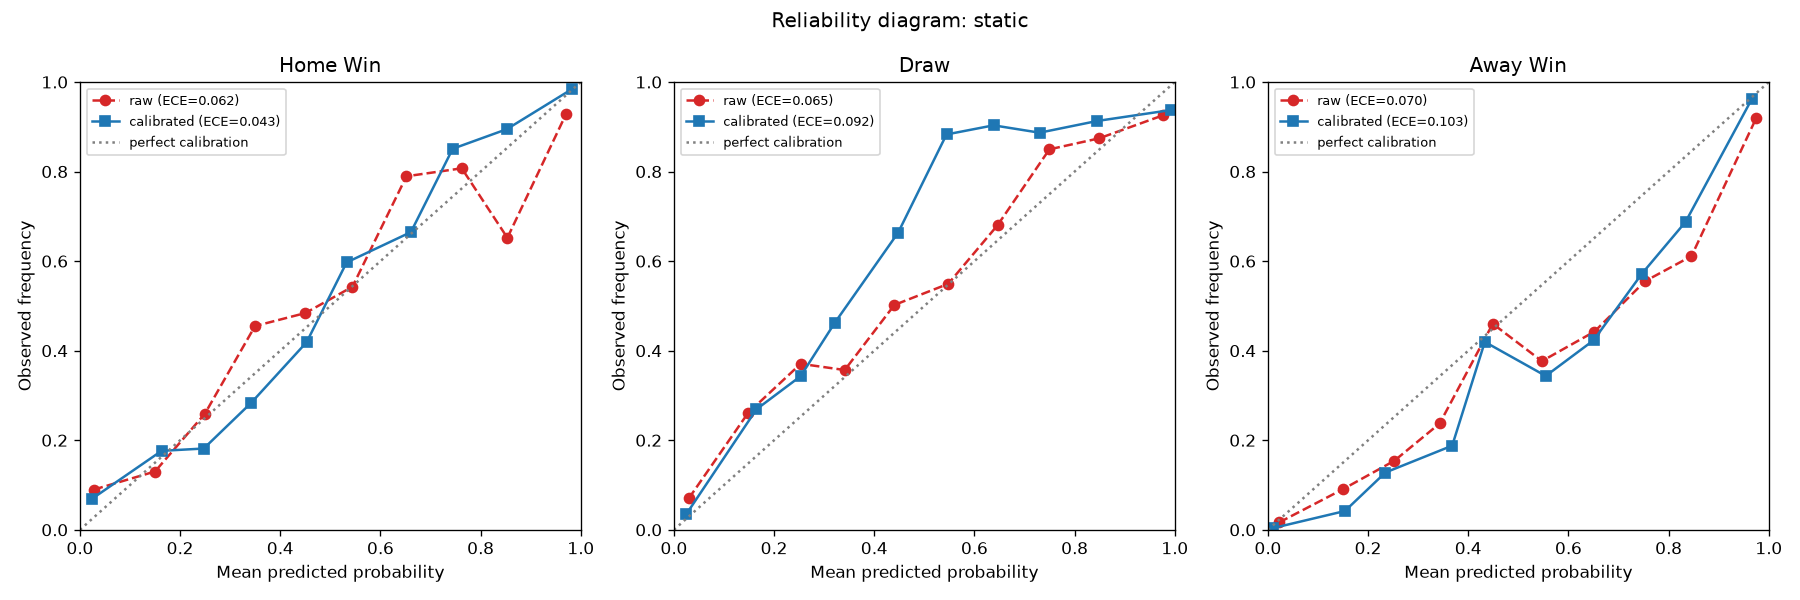

In [16]:
from IPython.display import Image, display

img_path = Path(REPO_ROOT / "calibration/plots/static_reliability.png")
if img_path.exists():
    display(Image(filename=str(img_path)))
else:
    print("Run calibration/run.py first to generate this plot.")


In [17]:
calib_results = json.loads(Path(REPO_ROOT / "data/processed/calibration/calibration_results.json").read_text())
rows = []
for r in calib_results:
    for cls, vals in r["classes"].items():
        rows.append({"model": r["model"], "class": cls, "raw_ece": vals["raw"]["ece"], "isotonic_ece": vals["isotonic"]["ece"]})
pd.DataFrame(rows).pivot(index="model", columns="class", values=["raw_ece", "isotonic_ece"]).round(3)


raw_ece                 isotonic_ece                
class    away_win   draw home_win     away_win   draw home_win
model                                                         
bayesian    0.062  0.062    0.056        0.099  0.089    0.044
gbm         0.079  0.047    0.045        0.077  0.093    0.038
static      0.070  0.065    0.062        0.103  0.092    0.043

**Headline finding: calibration mostly does NOT help here, for a real,
checkable reason.** `home_win` calibration works as expected (isotonic
regression improves ECE for all three models). `draw` and `away_win`
calibration makes things *worse*, consistently, across every model. This
traces to a specific cause, not noise: the 43-match calibration split has
only **9 draw-outcome matches and 16 away-win matches** -- despite ~4,000
per-minute rows, the *effective* sample size for fitting each class's
correction is the match count, not the row count (rows from one match are
correlated, sharing the same outcome). Both calibrators overfit to that
handful of matches and generalize poorly to the 29 draws in the test set.
Practical recommendation: calibrate `home_win` with isotonic regression;
leave `draw`/`away_win` raw given this data volume.

## 9. Betting-Market Benchmark

Our models against real Pinnacle closing odds (de-vigged), pre-match and
in-game, using a naive market-plus-score-adjustment baseline for the
in-game comparison so the "whose prior is better" question is isolated.

In [18]:
market_comparison = json.loads(Path(REPO_ROOT / "data/processed/market_comparison.json").read_text())
print("Pre-match Brier score:")
display(pd.DataFrame(market_comparison["prematch"]).T)
print("\nIn-game Brier score:")
display(pd.DataFrame(market_comparison["ingame_overall"]).T)
print("\nThe market wins pre-match, as expected. In-game the gap narrows substantially (see market/README.md)")
print("but per the bootstrap analysis, is not statistically significant.")


Pre-match Brier score:


,brier,logloss
market,0.584953,0.976199
static,0.593278,0.987052
bayesian,0.596037,0.996398
gbm,0.651647,1.076953



In-game Brier score:


,brier,logloss
market,0.431996,0.772994
static,0.438371,0.781632
bayesian,0.434602,0.773937
gbm,0.461288,0.796036



The market wins pre-match, as expected. In-game the gap narrows substantially (see market/README.md)
but per the bootstrap analysis, is not statistically significant.


**A real bug caught here too.** The first run of this comparison showed
the market performing *catastrophically* (Brier 0.70+ pre-match, 0.86 in
the 60'+ phase -- worse than random guessing), implausible for a
professional market and correctly treated as a red flag rather than
reported. Root cause: the test DataFrame was independently re-sorted by
`(match_id, minute)` after predictions had already been computed from an
*unsorted* copy elsewhere -- same row count, silently misaligned rows.
Fixed by having the shared split function return the exact DataFrames its
predictions were computed from, rather than trusting two independent
calls to reproduce identical row order. Numbers shown above are post-fix,
and pass a basic plausibility check (market Brier ~0.585 pre-match is in
the range published soccer-prediction-market research typically reports).

**Also notable:** Pinnacle's mean overround was 2.04% -- notably tighter
than a typical recreational bookmaker (5-8%), consistent with its
reputation as the sharpest market and the reason it was chosen over e.g.
Bet365 for this benchmark.

## 10. Walk-Forward Validation & Statistical Rigor

Two analyses: (1) match-block bootstrap CIs on the 95-match in-game
comparison; (2) cross-season Dixon-Coles walk-forward across all 33
seasons -- the one model that doesn't need StatsBomb's single-season data.

In [19]:
ingame_boot = json.loads(Path(REPO_ROOT / "data/processed/ingame_bootstrap.json").read_text())
print("Per-model Brier score with 95% CI (95 test matches):")
for name, ci in ingame_boot["per_model_ci"].items():
    print(f"  {name:10s}: {ci['point']:.4f}  [{ci['ci_lo']:.4f}, {ci['ci_hi']:.4f}]")

walkforward = json.loads(Path(REPO_ROOT / "data/processed/season_walkforward.json").read_text())
print(f"\nCross-season walk-forward ({walkforward['n_matches']:,} matches, {walkforward['n_season_transitions']} season-transitions):")
for name, ci in walkforward["per_model_ci"].items():
    print(f"  {name:14s}: {ci['point']:.4f}  [{ci['ci_lo']:.4f}, {ci['ci_hi']:.4f}]")
diff = walkforward["walkforward_vs_insample_diff"]
print(f"\nWalk-forward - in-sample: {diff['point_diff']:+.4f}  [{diff['ci_lo']:+.4f}, {diff['ci_hi']:+.4f}]  "
      f"({'significant' if diff['significant_at_95'] else 'not significant'})")


Per-model Brier score with 95% CI (95 test matches):
  market    : 0.4320  [0.3637, 0.5034]
  static    : 0.4384  [0.3705, 0.5119]
  bayesian  : 0.4346  [0.3695, 0.5041]
  gbm       : 0.4613  [0.4050, 0.5226]

Cross-season walk-forward (8,808 matches, 32 season-transitions):
  walk_forward  : 0.6033  [0.5964, 0.6102]
  in_sample     : 0.5697  [0.5627, 0.5765]

Walk-forward - in-sample: +0.0336  [+0.0291, +0.0377]  (significant)


## 11. Results & Honest Comparison

The full synthesis is in `RESULTS.md`. Four central questions, answered
directly:

1. **Does gradient boosting beat the statistical baselines?** No overall,
   but yes specifically in the first 30 minutes of a match -- a real,
   demonstrated early-match advantage, not a wholesale win.
2. **Does it beat the betting market, pre-match or in-game?** Neither, at
   the confidence this data supports -- the market wins pre-match as
   expected, and the in-game gap shrinks a lot but isn't statistically
   significant.
3. **Is draw prediction meaningfully worse?** Yes, but specifically via
   discrimination -- across 95 test matches, no model *ever* predicted a
   draw as the most likely outcome, despite draws happening 30.5% of the
   time. Not uniformly true of calibration error, though (away-win is
   sometimes worse-calibrated than draw).
4. **Does hierarchical Bayesian updating help?** Probably, but "probably"
   is doing real work -- 22/33 seasons directionally favor it, but the
   effect isn't statistically significant on the smaller matched sample.

Every "not proven" traces back to the same root cause: StatsBomb's free
open data covers exactly one general-purpose EPL season, capping every
event-level comparison at a 95-match held-out test. Where this project
could use purely goals-based data across all 33 seasons (the walk-forward
analysis), the same kinds of questions get answered with real, tight
confidence. **That contrast is the project's most important methodological
finding, not just a caveat to it.**

In [20]:
final_comparison = json.loads(Path(REPO_ROOT / "data/processed/final_comparison.json").read_text())
for phase in ["prematch", "ingame"]:
    print(f"--- {phase} per-class Brier score, 95% CI ---")
    for model, classes in final_comparison[phase].items():
        for cls, ci in classes.items():
            print(f"  {model:10s} {cls:10s}: {ci['point']:.4f}  [{ci['ci_lo']:.4f}, {ci['ci_hi']:.4f}]")
    print()


--- prematch per-class Brier score, 95% CI ---
  market     home_win  : 0.2044  [0.1754, 0.2362]
  market     draw      : 0.2161  [0.1683, 0.2626]
  market     away_win  : 0.1645  [0.1319, 0.2005]
  static     home_win  : 0.2093  [0.1789, 0.2421]
  static     draw      : 0.2157  [0.1709, 0.2592]
  static     away_win  : 0.1684  [0.1336, 0.2056]
  bayesian   home_win  : 0.2150  [0.1935, 0.2384]
  bayesian   draw      : 0.2140  [0.1686, 0.2584]
  bayesian   away_win  : 0.1670  [0.1344, 0.2026]
  gbm        home_win  : 0.2518  [0.2258, 0.2794]
  gbm        draw      : 0.2116  [0.1767, 0.2465]
  gbm        away_win  : 0.1882  [0.1578, 0.2200]

--- ingame per-class Brier score, 95% CI ---
  market     home_win  : 0.1484  [0.1161, 0.1834]
  market     draw      : 0.1719  [0.1348, 0.2113]
  market     away_win  : 0.1116  [0.0862, 0.1395]
  static     home_win  : 0.1517  [0.1195, 0.1862]
  static     draw      : 0.1738  [0.1362, 0.2134]
  static     away_win  : 0.1128  [0.0863, 0.1426]
  bayes

**The draw-discrimination finding, concretely:** across all 95 pre-match
test predictions, from all three models, draw was never once the
predicted (highest-probability) outcome -- despite occurring in 30.5% of
those matches. The highest pre-match draw probability any model ever
assigned, across the entire test set, was 0.35 (static Dixon-Coles).

## 12. Testing & Validation

21 tests, ~13 seconds total (`tests/`). Two kinds: regression tests
formalizing sanity checks already done ad hoc in earlier steps, and
genuinely new validation -- parameter recovery on synthetic data,
posterior predictive checks, and calibration/bootstrap procedure
validation on data with a *known* ground truth. Two of these caught real,
instructive issues on the first run rather than just passing quietly.

**Dixon-Coles parameter recovery**: generated match results from a
Dixon-Coles process with known true attack/defense/home_adv/rho, fit the
model, checked recovery. First attempt failed on defense correlation and
rho's sign at a realistic single-season sample size (380 matches) --
verified this was a genuine statistical power limit (3x the data fixes it
cleanly), which directly explains the real-data rho sign instability
already seen across individual seasons in the static Dixon-Coles fits.

**Possession-value (xT) synthetic test**: the first construction (a toy
pitch with deterministic, always-succeeding transitions toward goal)
produced a perfectly *flat* value grid, not an increasing one. That's
actually correct behavior, not a bug -- with a guaranteed eventual shot
and no discounting, position doesn't matter; it's specifically turnover
risk shrinking near goal that creates the real monotonic gradient. Fixed
by adding explicit turnover risk to the synthetic construction.

**Bayesian posterior predictive check**: simulated full seasons of goals
from 200 real posterior draws (not just the posterior mean) and confirmed
the real season's mean goals/match and draw rate fall inside the
simulated 95% range -- a genuine generative check.

**Calibration validation**: deliberately distorted synthetic probabilities
with a known overconfidence bias (cubed and renormalized) and confirmed
both Platt scaling and isotonic regression cut the resulting calibration
error by at least 40% on held-out data.

**Bootstrap validation**: confirmed match-block resampling gives
meaningfully wider (more honest) confidence intervals than naive
row-level resampling on data with strong within-match correlation -- the
actual justification for blocking by match throughout calibration/ and
backtest/ -- plus a planted-difference detection test and a false-positive check.

In [21]:
import subprocess
result = subprocess.run([sys.executable, "-m", "pytest", "tests/", "-q"], capture_output=True, text=True, cwd=str(REPO_ROOT))
print(result.stdout[-1500:])


.....................                                                    [100%]
21 passed in 12.62s



## Conclusion

This project set out to build a real, calibrated, honestly-benchmarked
in-game win probability model for EPL soccer -- and to disclose every
constraint and judgment call along the way rather than only the results
that flatter the approach. The single biggest constraint (StatsBomb's
380-match, one-season coverage, disclosed from the start) shaped
nearly every downstream finding, most visibly in the contrast between
the walk-forward validation's two analyses: 95 matches isn't enough to cleanly separate close
models, 8,808 matches is. Two independent bugs were caught and fixed
during development (an `arviz` rounding default in the Bayesian model, a DataFrame
row-alignment issue in the market benchmark) specifically because implausible results
were treated as red flags rather than reported at face value -- the same
discipline applied throughout, including in this notebook's synthetic
test suite, which surfaced two genuinely informative modeling insights
(estimator sample-size limits, and the role of turnover risk in the xT
value function) by *failing* on first attempt rather than being written
to pass.